In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from neuralprophet import NeuralProphet

In [2]:
df = pd.read_csv("../src/util/aws/vertica/vertica_data_20230530.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 939272 entries, 0 to 939271
Data columns (total 27 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   holdout            939272 non-null  int64  
 1   conversion         939272 non-null  int64  
 2   AMP_CLICK_DAY      939272 non-null  object 
 3   AMP_CLICK_HOUR     939272 non-null  int64  
 4   ACCOUNT_ID         939272 non-null  int64  
 5   CAMPAIGN_ID        939272 non-null  int64  
 6   ADGROUP_ID         939272 non-null  int64  
 7   KEYWORD_ID         939272 non-null  int64  
 8   CREATIVE_ID        939272 non-null  int64  
 9   ADCOPY_ID          939272 non-null  int64  
 10  PUBLISHER_ID       939272 non-null  int64  
 11  PUB_ATS_ID         939272 non-null  int64  
 12  PLACEMENT_ID       939272 non-null  int64  
 13  DEVICE_GROUP_ID    939272 non-null  int64  
 14  DEVICE_TYPE_ID     939272 non-null  int64  
 15  PUB_SUB_1          939272 non-null  object 
 16  PU

In [4]:
df['ds'] = pd.to_datetime(df['AMP_CLICK_DAY'], format = '%Y-%m-%d').dt.date

### ACCOUNT Level Prediction

In [5]:
combs = [
'ACCOUNT_ID'
]

In [6]:
df_agg = df[df['conversion']==1].groupby([*combs, 'ds']).agg({'order_value': 'sum', 'VALID_CLICKS': 'sum'}).reset_index()
df_agg['aov'] = df_agg['order_value'] / df_agg['VALID_CLICKS']
df_agg.sort_values([*combs, 'ds'])

,ACCOUNT_ID,ds,order_value,VALID_CLICKS,aov
0,74521,2022-12-01,93958.04,734,128.008229
1,74521,2022-12-02,136559.53,1006,135.745060
2,74521,2022-12-03,147489.96,1034,142.640193
3,74521,2022-12-04,116276.91,859,135.363108
4,74521,2022-12-05,152186.43,1077,141.305877
...,...,...,...,...,...
175,74521,2023-05-25,39887.06,310,128.667935
176,74521,2023-05-26,42476.15,323,131.505108
177,74521,2023-05-27,46539.69,329,141.458024
178,74521,2023-05-28,27084.11,220,123.109591


In [9]:
ts_data = pd.DataFrame({
    'ds': df_agg.ds,
    'y': np.log(df_agg.aov)
               })

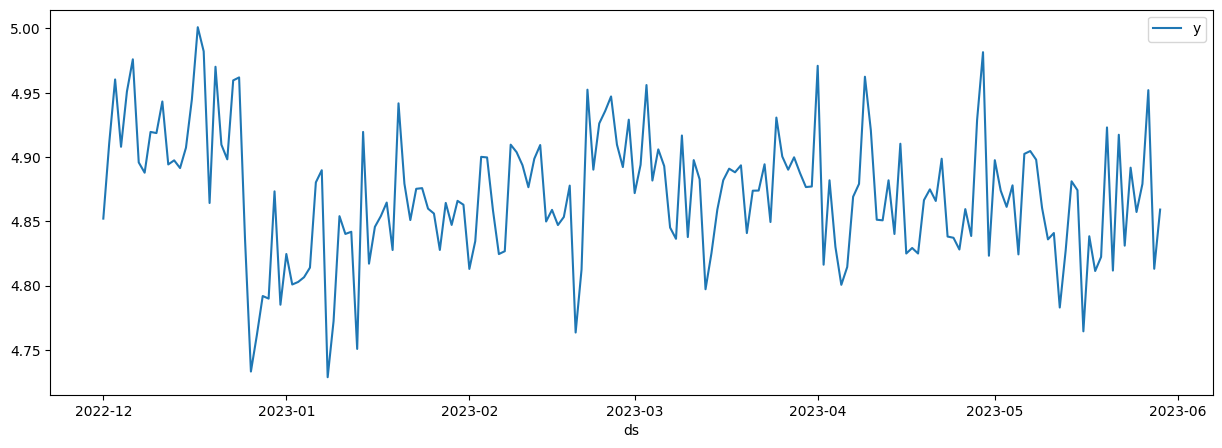

In [10]:
fig = ts_data.plot(x="ds", y=["y"], figsize=(15, 5))

### Setting up the model

To model future regressors, both past and future values of these regressors have to be known. So in contrast to the lagged regressors in the previous tutorial, future regressors also have a forecasted value for the future in addition to the historic values.

WARNING - (py.warnings._showwarnmsg) - /Users/lhuang/Project/Git/ml-test/venv/lib/python3.8/site-packages/pytorch_lightning/trainer/setup.py:201: UserWarning: MPS available but not used. Set `accelerator` and `devices` using `Trainer(accelerator='mps', devices=1)`.
  rank_zero_warn(



Finding best initial lr:   0%|          | 0/211 [00:00<?, ?it/s]

Training: 0it [00:00, ?it/s]

Predicting: 11it [00:00, ?it/s]

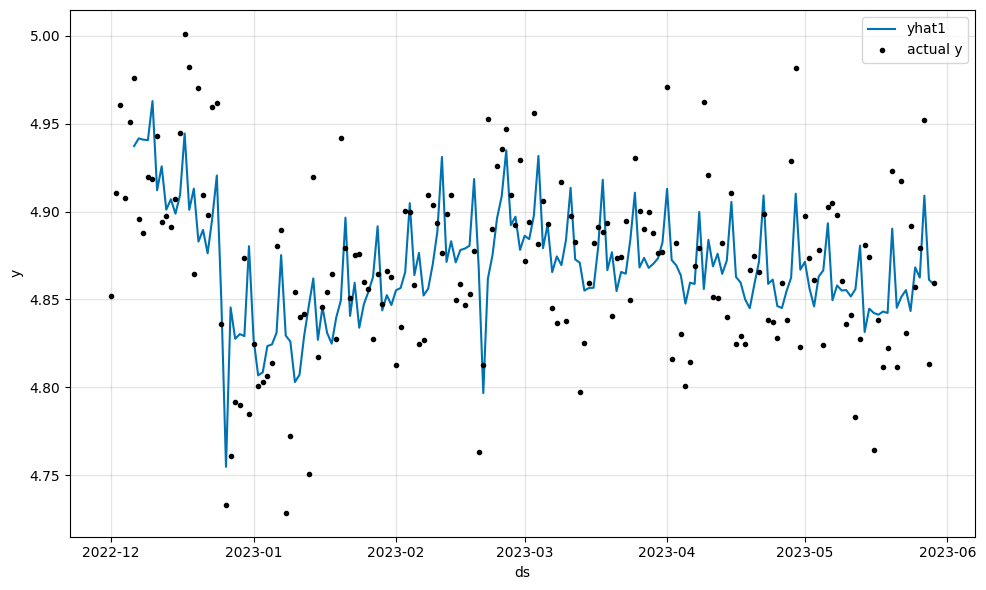

In [11]:
# Import the NeuralProphet class
from neuralprophet import NeuralProphet, set_log_level

# Disable logging messages unless there is an error
set_log_level("ERROR")

# Create a NeuralProphet model with default parameters
m = NeuralProphet(
    # Disable change trendpoints
    n_changepoints=0,
    # Disable seasonality components
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    n_lags=5,
)

# Use static plotly in notebooks
m.set_plotting_backend("matplotlib")

m = m.add_country_holidays("US")

# Fit the model on the dataset (this might take a bit)
metrics = m.fit(ts_data)
forecast = m.predict(ts_data)
m.plot(forecast)

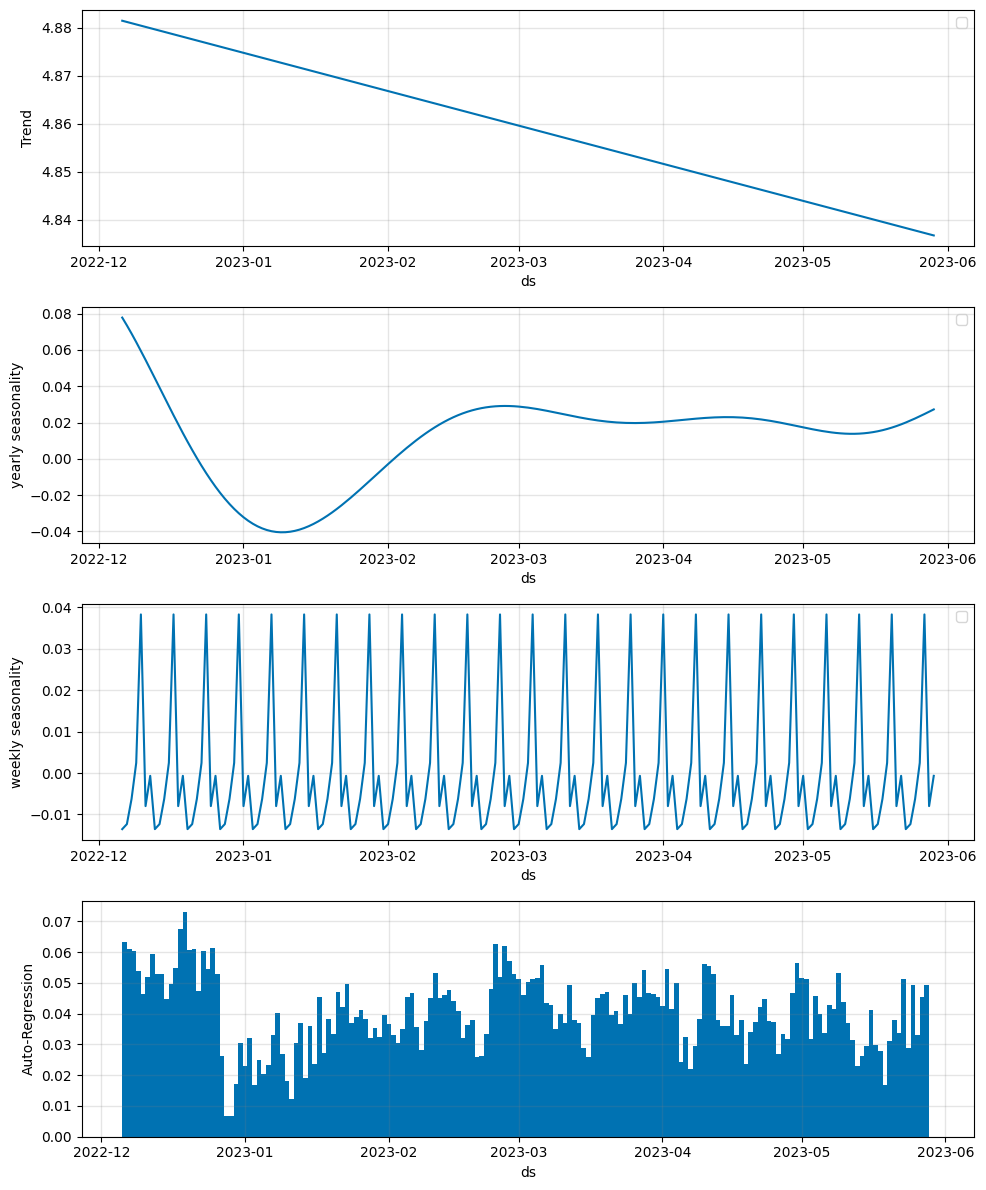

In [12]:
m.plot_components(forecast)

In [13]:
metrics

,MAE,RMSE,Loss,RegLoss,epoch
0,0.214295,0.252145,0.400554,0.0,0
1,0.212230,0.250529,0.394659,0.0,1
2,0.209737,0.247505,0.388066,0.0,2
3,0.207352,0.244742,0.381765,0.0,3
4,0.204243,0.243371,0.373677,0.0,4
...,...,...,...,...,...
386,0.031457,0.038291,0.010431,0.0,386
387,0.031532,0.038661,0.010480,0.0,387
388,0.031448,0.037913,0.010417,0.0,388
389,0.031444,0.038428,0.010433,0.0,389


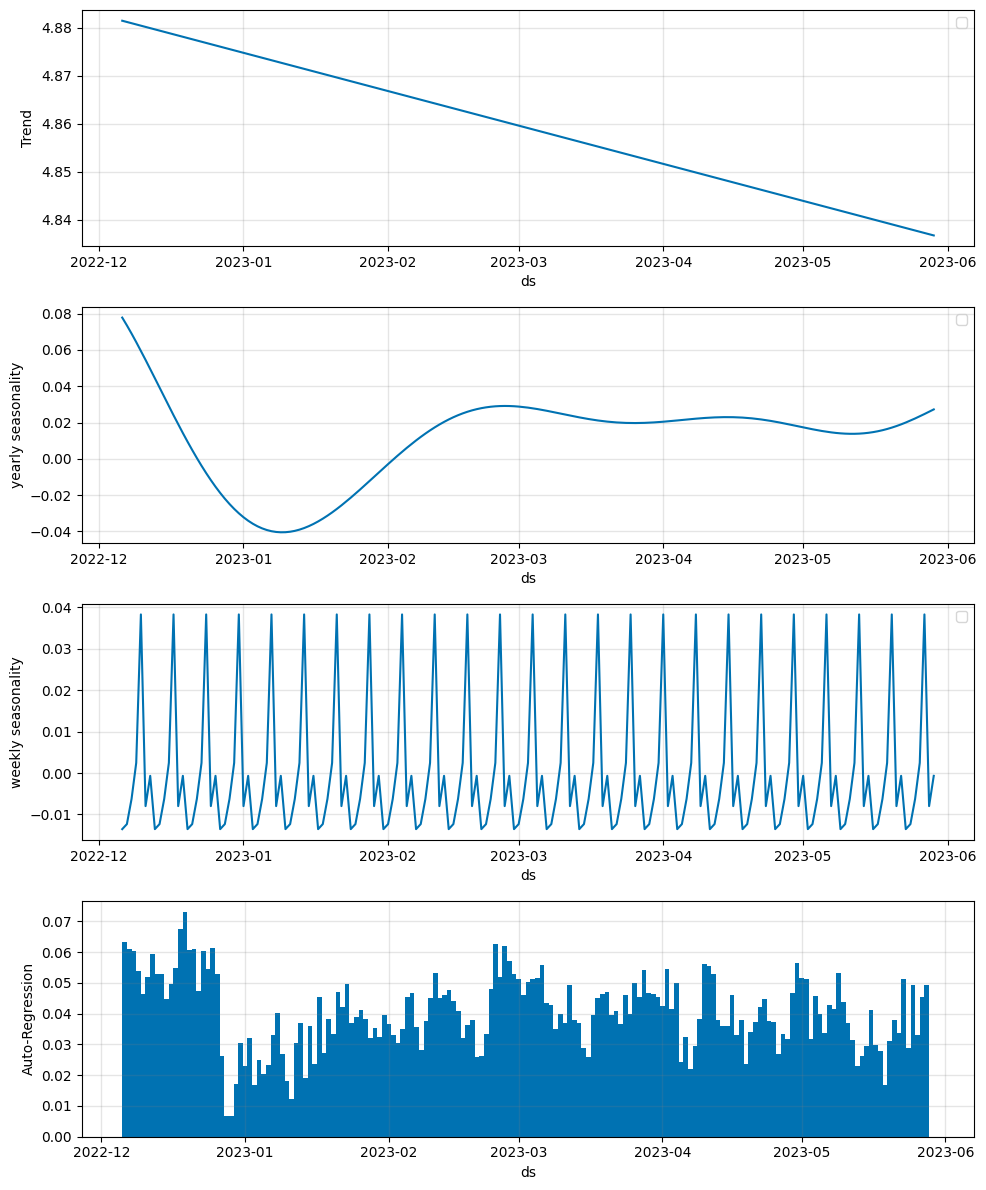

In [15]:
m.plot_components(forecast)

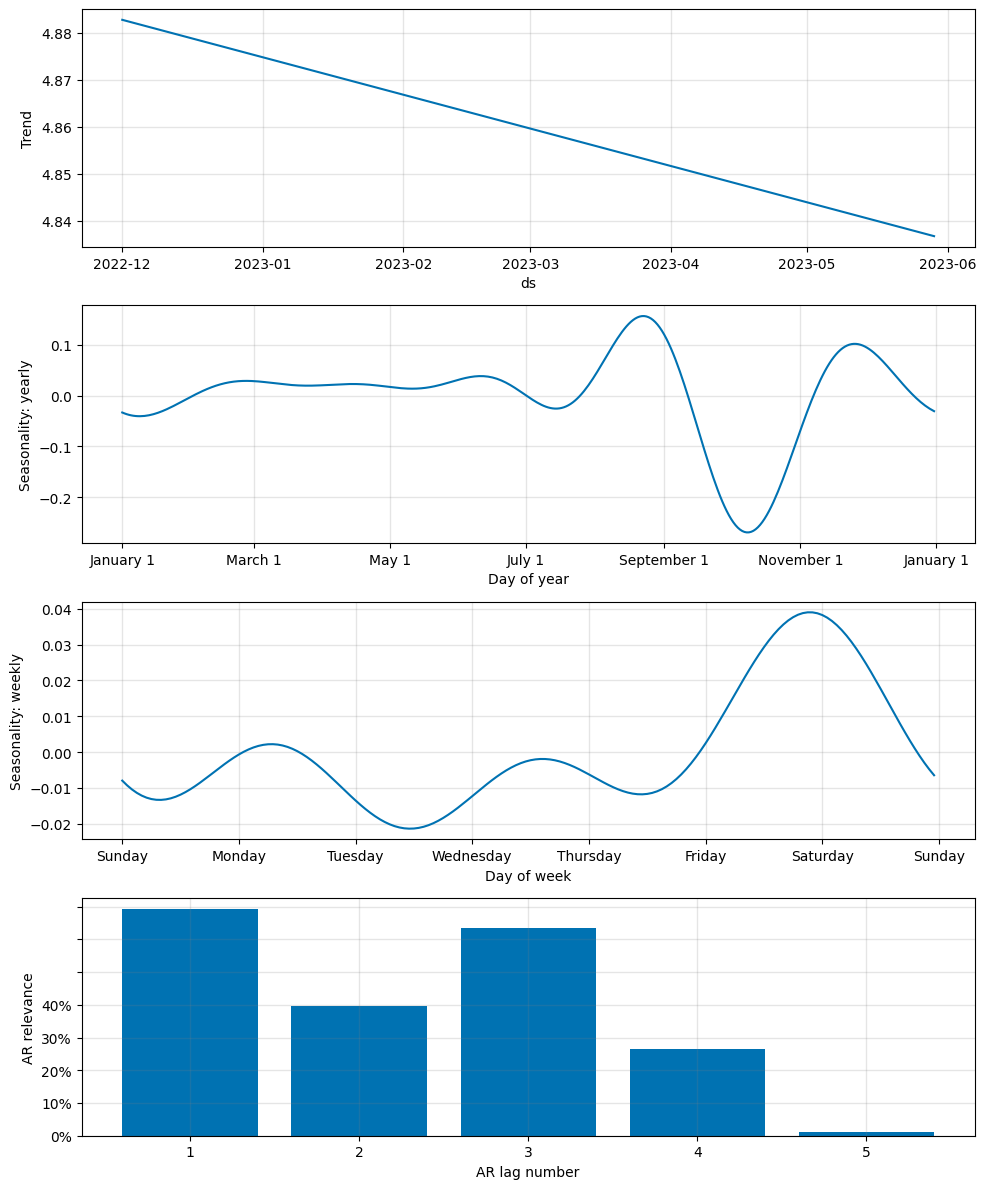

In [16]:
m.plot_parameters()

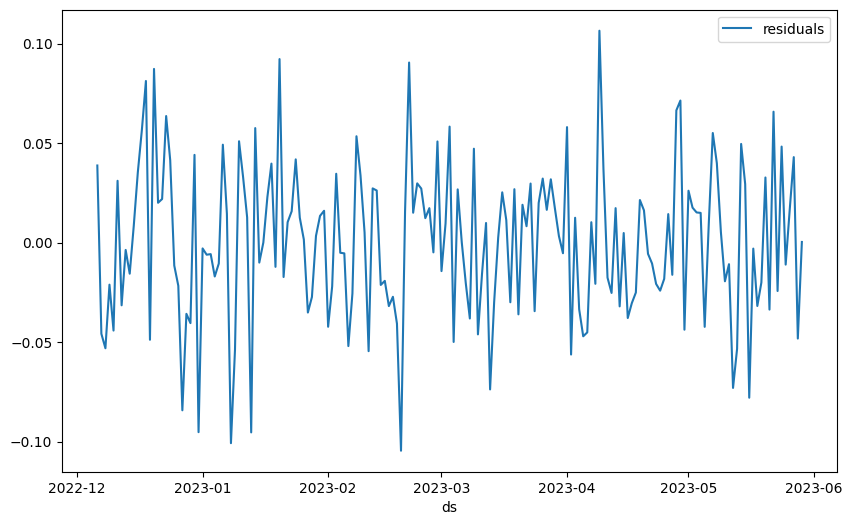

In [17]:
df_residuals = pd.DataFrame({"ds": ts_data["ds"], "residuals": ts_data["y"] - forecast["yhat1"]})
fig = df_residuals.plot(x="ds", y="residuals", figsize=(10, 6))